In [1]:
import sys
from pathlib import Path
import importlib

%load_ext autoreload
%autoreload 2

current = Path.cwd()

if (current / "ultrasound_tracker").exists():
    PROJECT_ROOT = current
elif (current.parent / "ultrasound_tracker").exists():
    PROJECT_ROOT = current.parent
else:
    raise FileNotFoundError("Could not find ultrasound_tracker folder")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /Users/grosbedou/PycharmProjects/NDORMS


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

import ultrasound_tracker.roi as roi
import ultrasound_tracker.geometry as geom
import ultrasound_tracker.utils as ut

from ultrasound_tracker.aponeurosis_detector import AponeurosisDetector
from ultrasound_tracker.frangi_detector import FrangiDetector
from ultrasound_tracker.hough_detector import HoughDetector

roi = importlib.reload(roi)
geom = importlib.reload(geom)
ut = importlib.reload(ut)

print("ROI file:", roi.__file__)
print("Geometry file:", geom.__file__)
print("Utils file:", ut.__file__)

print("roi conversions:", hasattr(roi, "line_local_to_global"), hasattr(roi, "lines_local_to_global"))
print("geometry helpers:", hasattr(geom, "pick_best_fascicle_line"), hasattr(geom, "compute_fascicle_geometry"))
print("utils drawing:", hasattr(ut, "draw_line_on_image"), hasattr(ut, "draw_lines_on_image"))

ROI file: /Users/grosbedou/PycharmProjects/NDORMS/ultrasound_tracker/roi.py
Geometry file: /Users/grosbedou/PycharmProjects/NDORMS/ultrasound_tracker/geometry.py
Utils file: /Users/grosbedou/PycharmProjects/NDORMS/ultrasound_tracker/utils.py
roi conversions: True True
geometry helpers: True True
utils drawing: True True


In [3]:
VIDEO_PATH = PROJECT_ROOT / "data" / "raw" / "UltraTimTrack_test.mp4"
ROI_PATH = PROJECT_ROOT / "data" / "rois" / "UltraTimTrack_test_rois.json"

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

OUT_CSV = RESULTS_DIR / "timtrack_sequence_features.csv"
OUT_NPZ = RESULTS_DIR / "timtrack_sequence_features_arrays.npz"

# Pour tester rapidement, mets FRAME_END = 100.
# Pour toute la vidéo, laisse FRAME_END = None.
FRAME_START = 0
FRAME_END = None
FRAME_STEP = 1

# Choix du détecteur fascicule.
# "frangi" = ton FrangiDetector.
# "hough" = ton HoughDetector.
FASCICLE_METHOD = "frangi"

print("VIDEO_PATH:", VIDEO_PATH)
print("ROI_PATH:", ROI_PATH)
print("OUT_CSV:", OUT_CSV)
print("OUT_NPZ:", OUT_NPZ)

VIDEO_PATH: /Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4
ROI_PATH: /Users/grosbedou/PycharmProjects/NDORMS/data/rois/UltraTimTrack_test_rois.json
OUT_CSV: /Users/grosbedou/PycharmProjects/NDORMS/results/timtrack_sequence_features.csv
OUT_NPZ: /Users/grosbedou/PycharmProjects/NDORMS/results/timtrack_sequence_features_arrays.npz


FPS: 33.341
Number of frames: 2667
Frame shape: (562, 706)
ROIs: {'superficial': (15, 21, 690, 42), 'deep': (16, 298, 689, 76), 'fascicle': (17, 65, 686, 226)}


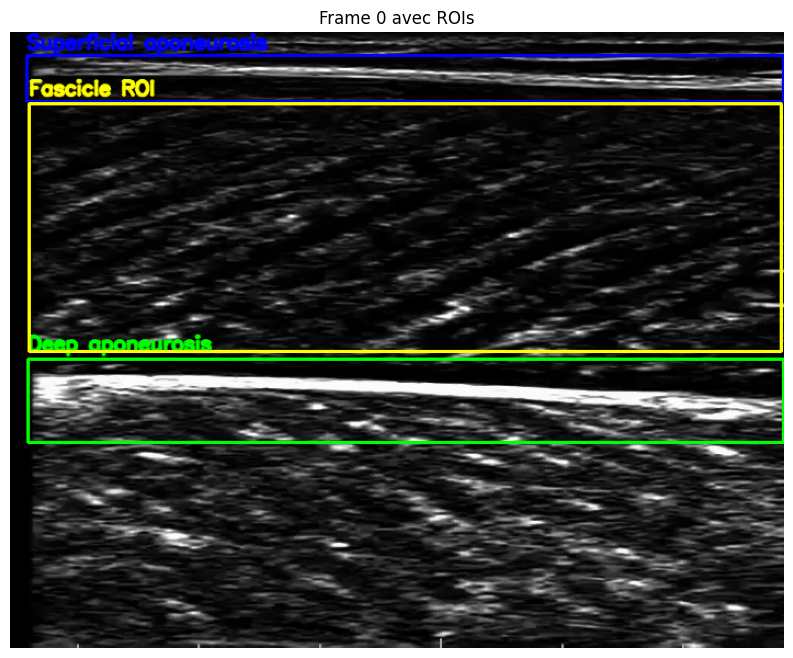

In [4]:
rois = roi.load_rois(ROI_PATH)

cap = cv2.VideoCapture(str(VIDEO_PATH))
fps = cap.get(cv2.CAP_PROP_FPS)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

ret, frame0 = cap.read()
cap.release()

if not ret:
    raise RuntimeError(f"Could not read video: {VIDEO_PATH}")

if frame0.ndim == 3:
    frame0_gray = cv2.cvtColor(frame0, cv2.COLOR_BGR2GRAY)
else:
    frame0_gray = frame0.copy()

print("FPS:", fps)
print("Number of frames:", n_frames)
print("Frame shape:", frame0_gray.shape)
print("ROIs:", rois)

vis_rois = roi.draw_rois(frame0_gray, rois)

plt.figure(figsize=(14, 8))
plt.imshow(vis_rois[..., ::-1])
plt.title("Frame 0 avec ROIs")
plt.axis("off")
plt.show()

In [5]:
apo_detector = AponeurosisDetector(
    method="frangi",
    sigma=10.0,
    th=0.5,
    filtfac=1.0,
    maxlengthratio=0.9,
    frangi_scale_range=(18, 20),
    frangi_scale_ratio=1,
    frangi_black_ridges=False,
    apomargin=20,
    napo=10,
    fillgap=50,
    fit_method="enforce_maxangle",
    maxangle=0.5,
    adaptive_block_size=51,
)

fas_frangi_detector = FrangiDetector(
    sigmas=(1, 2, 4),
    alpha=0.5,
    beta=15.0,
    black_ridges=False,
    threshold=0.08,
    angle_min=10,
    angle_max=70,
    hough_threshold=15,
    min_line_length=25,
    max_line_gap=15,
)

fas_hough_detector = HoughDetector(
    angle_min=10,
    angle_max=70,
    canny_low=30,
    canny_high=90,
    hough_threshold=50,
    min_line_length=30,
    max_line_gap=10,
)

print("Aponeurosis detector: Frangi")
print("Fascicle detector:", FASCICLE_METHOD)

Aponeurosis detector: Frangi
Fascicle detector: frangi


In [6]:
if FRAME_END is None:
    frame_end_effective = n_frames
else:
    frame_end_effective = min(FRAME_END, n_frames)

frame_indices = list(range(FRAME_START, frame_end_effective, FRAME_STEP))

print("Frames to process:", len(frame_indices))
print("First frame:", frame_indices[0])
print("Last frame:", frame_indices[-1])

Frames to process: 2667
First frame: 0
Last frame: 2666


In [7]:
results = {
    "frame": [],
    "time_s": [],
    "success": [],
    "fascicle_length_px": [],
    "fascicle_angle_deg": [],
    "deep_apo_angle_deg": [],
    "pennation_angle_deg": [],
    "n_fascicle_candidates": [],
    "error": [],
}

sup_apo_lines = []
deep_apo_lines = []
fascicle_lines = []
fascicle_segments = []
sup_attachments = []
deep_attachments = []

In [8]:
cap = cv2.VideoCapture(str(VIDEO_PATH))

current_target_idx = 0
target_frames = set(frame_indices)

for frame_idx in range(n_frames):
    ret, frame = cap.read()

    if not ret:
        break

    if frame_idx not in target_frames:
        continue

    if frame.ndim == 3:
        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    else:
        frame_gray = frame.copy()

    time_s = frame_idx / fps if fps and fps > 0 else np.nan

    # Default failed outputs
    success = False
    error_msg = ""
    n_candidates = 0

    sup_line_global = np.full(4, np.nan, dtype=np.float32)
    deep_line_global = np.full(4, np.nan, dtype=np.float32)
    fas_best_line_global = np.full(4, np.nan, dtype=np.float32)
    fas_segment = np.full(4, np.nan, dtype=np.float32)
    sup_attachment = np.full(2, np.nan, dtype=np.float32)
    deep_attachment = np.full(2, np.nan, dtype=np.float32)

    fascicle_length_px = np.nan
    fascicle_angle_deg = np.nan
    deep_apo_angle_deg = np.nan
    pennation_angle_deg = np.nan

    try:
        # 1. Extract ROIs
        sup_img = roi.extract_roi(frame_gray, rois["superficial"])
        deep_img = roi.extract_roi(frame_gray, rois["deep"])
        fas_img = roi.extract_roi(frame_gray, rois["fascicle"])

        # 2. Detect superficial aponeurosis
        sup_result = apo_detector.detect(sup_img, kind="superficial")
        sup_line_local = sup_result["line_local"]
        sup_line_tmp = roi.line_local_to_global(sup_line_local, rois["superficial"])

        # 3. Detect deep aponeurosis
        deep_result = apo_detector.detect(deep_img, kind="deep")
        deep_line_local = deep_result["line_local"]
        deep_line_tmp = roi.line_local_to_global(deep_line_local, rois["deep"])

        if sup_line_tmp is None:
            raise RuntimeError("No superficial aponeurosis detected.")

        if deep_line_tmp is None:
            raise RuntimeError("No deep aponeurosis detected.")

        # 4. Detect fascicle candidates
        if FASCICLE_METHOD.lower() == "frangi":
            fas_lines_local, fas_angles, fas_lengths = fas_frangi_detector.detect(fas_img)

        elif FASCICLE_METHOD.lower() == "hough":
            fas_lines_local, fas_angles, fas_lengths = fas_hough_detector.detect(fas_img)

        else:
            raise ValueError("FASCICLE_METHOD must be 'frangi' or 'hough'.")

        fas_lines_global = roi.lines_local_to_global(fas_lines_local, rois["fascicle"])

        n_candidates = 0 if fas_lines_global is None else len(fas_lines_global)

        fas_best_tmp = geom.pick_best_fascicle_line(
            fas_lines_global,
            lengths=fas_lengths,
            superficial_apo_line=sup_line_tmp,
            deep_apo_line=deep_line_tmp,
            frame_shape=frame_gray.shape,
            margin=50,
        )

        if fas_best_tmp is None:
            raise RuntimeError("No fascicle line selected.")

        # 5. Compute geometry
        geometry_features = geom.compute_fascicle_geometry(
            superficial_apo_line=sup_line_tmp,
            deep_apo_line=deep_line_tmp,
            fascicle_line=fas_best_tmp,
        )

        # 6. Store successful outputs
        success = True

        sup_line_global = np.asarray(sup_line_tmp, dtype=np.float32)
        deep_line_global = np.asarray(deep_line_tmp, dtype=np.float32)
        fas_best_line_global = np.asarray(fas_best_tmp, dtype=np.float32)

        fas_segment = np.asarray(
            geometry_features["fascicle_segment_between_apos"],
            dtype=np.float32,
        )

        sup_attachment = np.asarray(
            geometry_features["sup_attachment"],
            dtype=np.float32,
        )

        deep_attachment = np.asarray(
            geometry_features["deep_attachment"],
            dtype=np.float32,
        )

        fascicle_length_px = geometry_features["fascicle_length_px"]
        fascicle_angle_deg = geometry_features["fascicle_angle_deg"]
        deep_apo_angle_deg = geometry_features["deep_apo_angle_deg"]
        pennation_angle_deg = geometry_features["pennation_angle_deg"]

    except Exception as exc:
        error_msg = str(exc)

    # Numeric results
    results["frame"].append(frame_idx)
    results["time_s"].append(time_s)
    results["success"].append(success)
    results["fascicle_length_px"].append(fascicle_length_px)
    results["fascicle_angle_deg"].append(fascicle_angle_deg)
    results["deep_apo_angle_deg"].append(deep_apo_angle_deg)
    results["pennation_angle_deg"].append(pennation_angle_deg)
    results["n_fascicle_candidates"].append(n_candidates)
    results["error"].append(error_msg)

    # Array results
    sup_apo_lines.append(sup_line_global)
    deep_apo_lines.append(deep_line_global)
    fascicle_lines.append(fas_best_line_global)
    fascicle_segments.append(fas_segment)
    sup_attachments.append(sup_attachment)
    deep_attachments.append(deep_attachment)

    if len(results["frame"]) % 100 == 0:
        n_done = len(results["frame"])
        n_success = int(np.sum(results["success"]))
        print(f"Processed {n_done}/{len(frame_indices)} frames | success={n_success}")

cap.release()

print("Done.")
print("Processed frames:", len(results["frame"]))
print("Successful frames:", int(np.sum(results["success"])))

Processed 100/2667 frames | success=100
Processed 200/2667 frames | success=200
Processed 300/2667 frames | success=300
Processed 400/2667 frames | success=400
Processed 500/2667 frames | success=500
Processed 600/2667 frames | success=600
Processed 700/2667 frames | success=700
Processed 800/2667 frames | success=800
Processed 900/2667 frames | success=900
Processed 1000/2667 frames | success=1000
Processed 1100/2667 frames | success=1100
Processed 1200/2667 frames | success=1200
Processed 1300/2667 frames | success=1300
Processed 1400/2667 frames | success=1400
Processed 1500/2667 frames | success=1500
Processed 1600/2667 frames | success=1600
Processed 1700/2667 frames | success=1700
Processed 1800/2667 frames | success=1800
Processed 1900/2667 frames | success=1900
Processed 2000/2667 frames | success=2000
Processed 2100/2667 frames | success=2100
Processed 2200/2667 frames | success=2200
Processed 2300/2667 frames | success=2300
Processed 2400/2667 frames | success=2400
Processed 

In [9]:
sup_apo_lines_arr = np.vstack(sup_apo_lines).astype(np.float32)
deep_apo_lines_arr = np.vstack(deep_apo_lines).astype(np.float32)
fascicle_lines_arr = np.vstack(fascicle_lines).astype(np.float32)
fascicle_segments_arr = np.vstack(fascicle_segments).astype(np.float32)
sup_attachments_arr = np.vstack(sup_attachments).astype(np.float32)
deep_attachments_arr = np.vstack(deep_attachments).astype(np.float32)

# Save numeric CSV using your existing utility
ut.save_results(results, str(OUT_CSV))

# Save arrays
np.savez(
    OUT_NPZ,
    frame=np.asarray(results["frame"], dtype=np.int32),
    time_s=np.asarray(results["time_s"], dtype=np.float32),
    success=np.asarray(results["success"], dtype=bool),
    sup_apo_lines=sup_apo_lines_arr,
    deep_apo_lines=deep_apo_lines_arr,
    fascicle_lines=fascicle_lines_arr,
    fascicle_segments=fascicle_segments_arr,
    sup_attachments=sup_attachments_arr,
    deep_attachments=deep_attachments_arr,
    fascicle_length_px=np.asarray(results["fascicle_length_px"], dtype=np.float32),
    fascicle_angle_deg=np.asarray(results["fascicle_angle_deg"], dtype=np.float32),
    deep_apo_angle_deg=np.asarray(results["deep_apo_angle_deg"], dtype=np.float32),
    pennation_angle_deg=np.asarray(results["pennation_angle_deg"], dtype=np.float32),
    n_fascicle_candidates=np.asarray(results["n_fascicle_candidates"], dtype=np.int32),
)

print("Saved CSV:", OUT_CSV)
print("Saved NPZ:", OUT_NPZ)

Résultats sauvegardés : /Users/grosbedou/PycharmProjects/NDORMS/results/timtrack_sequence_features.csv
Saved CSV: /Users/grosbedou/PycharmProjects/NDORMS/results/timtrack_sequence_features.csv
Saved NPZ: /Users/grosbedou/PycharmProjects/NDORMS/results/timtrack_sequence_features_arrays.npz


In [10]:
success_arr = np.asarray(results["success"], dtype=bool)
frames_arr = np.asarray(results["frame"])
time_arr = np.asarray(results["time_s"], dtype=np.float32)

length_arr = np.asarray(results["fascicle_length_px"], dtype=np.float32)
pennation_arr = np.asarray(results["pennation_angle_deg"], dtype=np.float32)
fascicle_angle_arr = np.asarray(results["fascicle_angle_deg"], dtype=np.float32)

print("Total processed:", len(success_arr))
print("Successful:", np.sum(success_arr))
print("Failed:", np.sum(~success_arr))
print("Success rate:", 100 * np.mean(success_arr), "%")

if np.any(success_arr):
    print("\nLength px:")
    print("  mean:", np.nanmean(length_arr))
    print("  std :", np.nanstd(length_arr))
    print("  min :", np.nanmin(length_arr))
    print("  max :", np.nanmax(length_arr))

    print("\nPennation deg:")
    print("  mean:", np.nanmean(pennation_arr))
    print("  std :", np.nanstd(pennation_arr))
    print("  min :", np.nanmin(pennation_arr))
    print("  max :", np.nanmax(pennation_arr))

# Show most common errors
errors = [e for e in results["error"] if e != ""]

print("\nNumber of error messages:", len(errors))

if len(errors) > 0:
    unique_errors = {}
    for e in errors:
        unique_errors[e] = unique_errors.get(e, 0) + 1

    print("\nTop errors:")
    for e, count in sorted(unique_errors.items(), key=lambda kv: kv[1], reverse=True)[:10]:
        print(f"{count}x : {e}")

Total processed: 2667
Successful: 2667
Failed: 0
Success rate: 100.0 %

Length px:
  mean: 762.6471
  std : 59.98428
  min : 470.68362
  max : 853.5027

Pennation deg:
  mean: 16.012983
  std : 13.664715
  min : -29.854645
  max : 33.99401

Number of error messages: 0


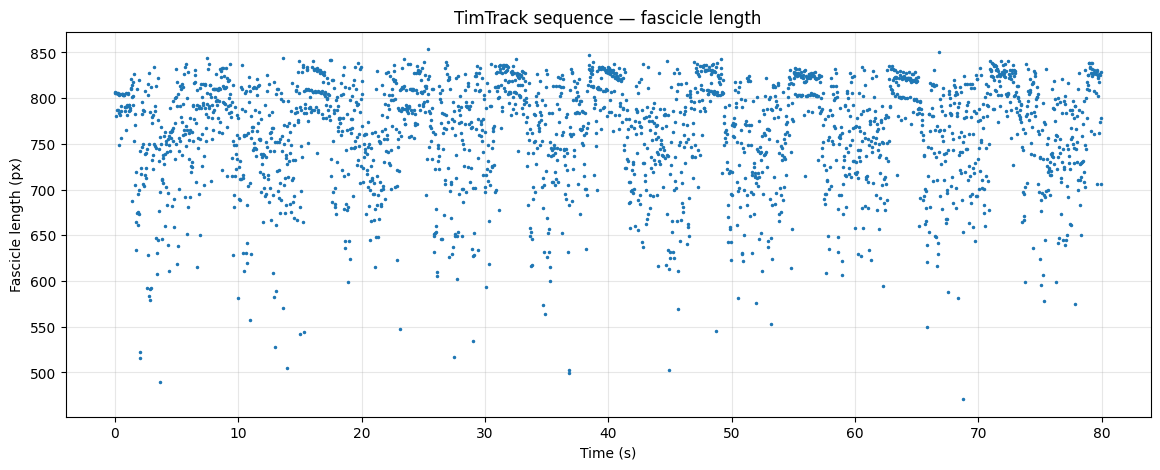

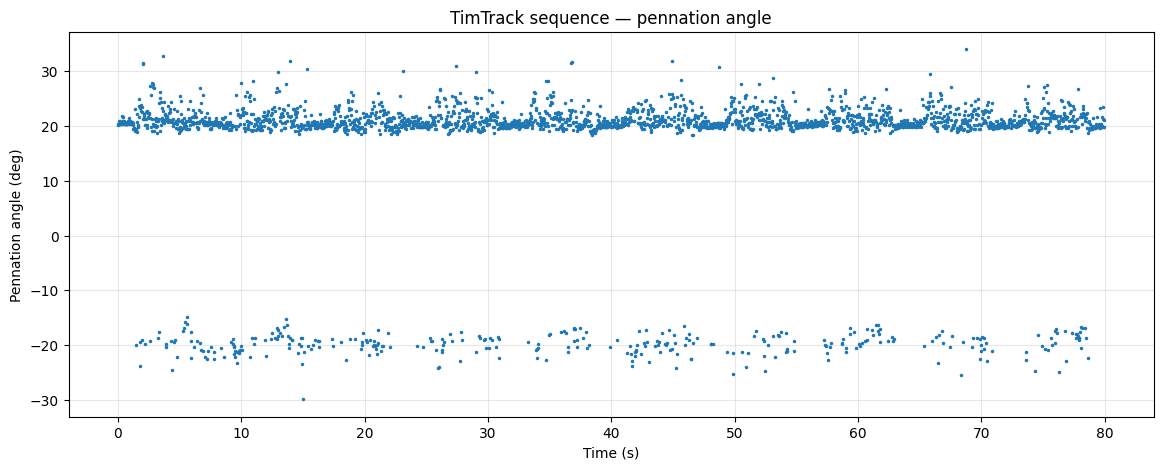

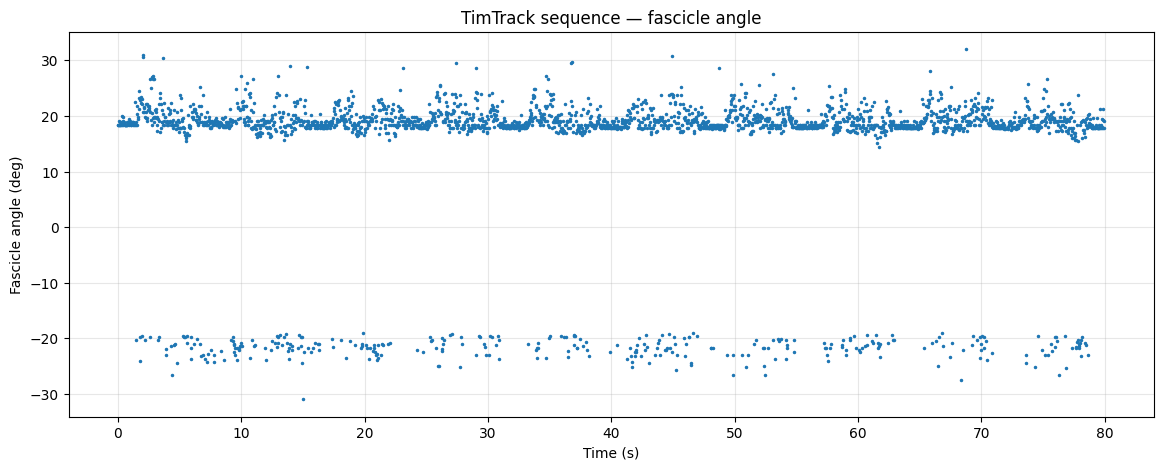

In [11]:
plt.figure(figsize=(14, 5))
plt.plot(time_arr, length_arr, ".", markersize=3)
plt.xlabel("Time (s)")
plt.ylabel("Fascicle length (px)")
plt.title("TimTrack sequence — fascicle length")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(time_arr, pennation_arr, ".", markersize=3)
plt.xlabel("Time (s)")
plt.ylabel("Pennation angle (deg)")
plt.title("TimTrack sequence — pennation angle")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(time_arr, fascicle_angle_arr, ".", markersize=3)
plt.xlabel("Time (s)")
plt.ylabel("Fascicle angle (deg)")
plt.title("TimTrack sequence — fascicle angle")
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
valid_indices = np.where(success_arr)[0]

if len(valid_indices) == 0:
    raise RuntimeError("No successful frames to visualize.")

selected_result_indices = [
    valid_indices[0],
    valid_indices[len(valid_indices) // 2],
    valid_indices[-1],
]

print("Selected result indices:", selected_result_indices)
print("Selected frame numbers:", [results["frame"][i] for i in selected_result_indices])

Selected result indices: [np.int64(0), np.int64(1333), np.int64(2666)]
Selected frame numbers: [0, 1333, 2666]


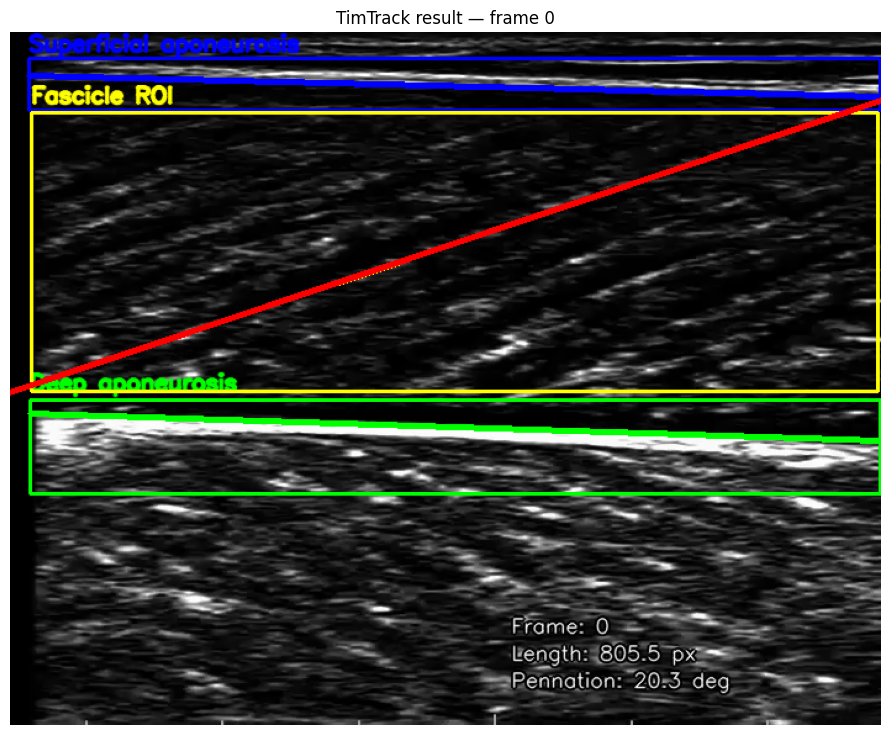

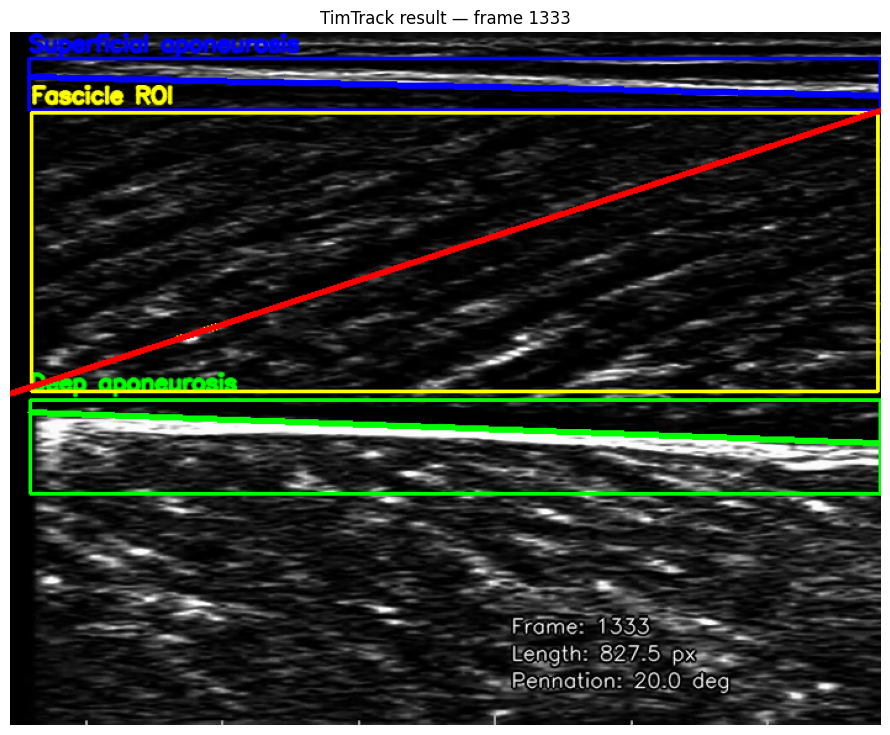

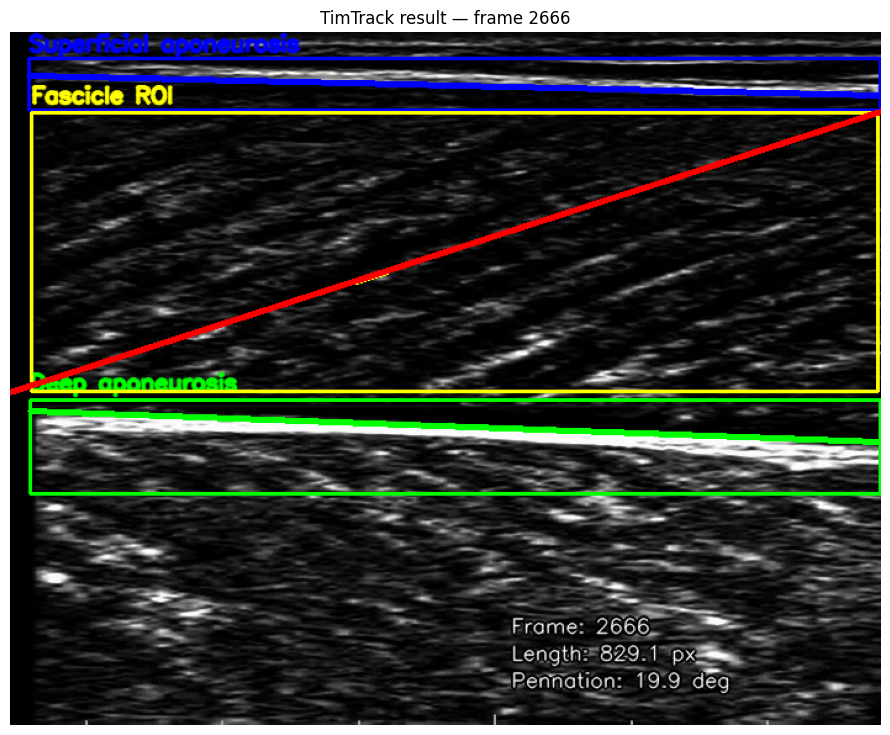

In [13]:
for result_idx in selected_result_indices:
    frame_idx = int(results["frame"][result_idx])

    cap = cv2.VideoCapture(str(VIDEO_PATH))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print("Could not read frame", frame_idx)
        continue

    if frame.ndim == 3:
        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    else:
        frame_gray = frame.copy()

    vis = roi.draw_rois(frame_gray, rois)

    ut.draw_line_on_image(vis, sup_apo_lines_arr[result_idx], color=(255, 0, 0), thickness=3)
    ut.draw_line_on_image(vis, deep_apo_lines_arr[result_idx], color=(0, 255, 0), thickness=3)
    ut.draw_line_on_image(vis, fascicle_lines_arr[result_idx], color=(0, 255, 255), thickness=3)
    ut.draw_line_on_image(vis, fascicle_segments_arr[result_idx], color=(0, 0, 255), thickness=4)

    ut.draw_points_on_image(
        vis,
        np.vstack([
            sup_attachments_arr[result_idx],
            deep_attachments_arr[result_idx],
        ]),
        color=(0, 0, 255),
        radius=6,
    )

    text_lines = [
        f"Frame: {frame_idx}",
        f"Length: {length_arr[result_idx]:.1f} px",
        f"Pennation: {pennation_arr[result_idx]:.1f} deg",
    ]

    ut.put_text_lines_on_image(
        vis,
        text_lines,
        origin=(frame_gray.shape[1] - 300, frame_gray.shape[0] - 75),
        line_spacing=22,
        font_scale=0.55,
        color=(255, 255, 255),
        outline_color=(0, 0, 0),
    )

    plt.figure(figsize=(16, 9))
    plt.imshow(vis[..., ::-1])
    plt.title(f"TimTrack result — frame {frame_idx}")
    plt.axis("off")
    plt.show()

In [14]:
loaded = np.load(OUT_NPZ, allow_pickle=True)

print("Loaded:", OUT_NPZ)
print("Keys:")
for key in loaded.files:
    print(" -", key, loaded[key].shape)

loaded_success = loaded["success"]
loaded_length = loaded["fascicle_length_px"]
loaded_pennation = loaded["pennation_angle_deg"]

print("\nReload check:")
print("Success rate:", 100 * np.mean(loaded_success), "%")
print("Mean length:", np.nanmean(loaded_length))
print("Mean pennation:", np.nanmean(loaded_pennation))

Loaded: /Users/grosbedou/PycharmProjects/NDORMS/results/timtrack_sequence_features_arrays.npz
Keys:
 - frame (2667,)
 - time_s (2667,)
 - success (2667,)
 - sup_apo_lines (2667, 4)
 - deep_apo_lines (2667, 4)
 - fascicle_lines (2667, 4)
 - fascicle_segments (2667, 4)
 - sup_attachments (2667, 2)
 - deep_attachments (2667, 2)
 - fascicle_length_px (2667,)
 - fascicle_angle_deg (2667,)
 - deep_apo_angle_deg (2667,)
 - pennation_angle_deg (2667,)
 - n_fascicle_candidates (2667,)

Reload check:
Success rate: 100.0 %
Mean length: 762.6471
Mean pennation: 16.012983
